# Neural Network From Scratch for Heart Disease Prediction

This notebook implements a feed-forward neural network for binary heart disease classification using NumPy from scratch.

The model is implemented without using high-level machine learning frameworks such as TensorFlow or PyTorch.

The implementation covers:

1. Parameter initialization
2. Forward propagation
3. Binary cross-entropy loss
4. Backpropagation
5. Gradient descent
6. Model training
7. Prediction and evaluation

In [470]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [471]:
X_train = np.load("../data/X_train_scaled.npy")
X_test = np.load("../data/X_test_scaled.npy")

y_train = np.load("../data/y_train.npy")
y_test = np.load("../data/y_test.npy")

feature_names = np.load(
    "../data/feature_names.npy",
    allow_pickle=True
)

In [472]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (242, 22)
X_test : (61, 22)
y_train: (242,)
y_test : (61,)


In [473]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_train: (242, 1)
y_test : (61, 1)


In [ ]:
y_train_flat = y_train.ravel()

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train_flat,
    test_size=0.20,
    random_state=42,
    stratify=y_train_flat
)

y_train_model = y_train_model.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print("X_train_model:", X_train_model.shape)
print("X_val        :", X_val.shape)
print("y_train_model:", y_train_model.shape)
print("y_val        :", y_val.shape)
print("X_test       :", X_test.shape)
print("y_test       :", y_test.shape)

X_train_model: (193, 22)
X_val        : (49, 22)
y_train_model: (193, 1)
y_val        : (49, 1)
X_test       : (61, 22)
y_test       : (61, 1)


## Neural Network Architecture

The network uses the following architecture:

**22 → 16 → 8 → 1**

- Input layer: 22 features
- Hidden layer 1: 16 neurons with ReLU
- Hidden layer 2: 8 neurons with ReLU
- Output layer: 1 neuron with Sigmoid

The model is intentionally small given the limited dataset size.

In [475]:
input_size = X_train_model.shape[1]

hidden1_size = 16
hidden2_size = 8
output_size = 1

print("Input size:", input_size)

Input size: 22


In [476]:
np.random.seed(42)

W1 = np.random.randn(
    input_size,
    hidden1_size
) * np.sqrt(2 / input_size)

b1 = np.zeros(
    (1, hidden1_size)
)

W2 = np.random.randn(
    hidden1_size,
    hidden2_size
) * np.sqrt(2 / hidden1_size)

b2 = np.zeros(
    (1, hidden2_size)
)

W3 = np.random.randn(
    hidden2_size,
    output_size
) * np.sqrt(2 / hidden2_size)

b3 = np.zeros(
    (1, output_size)
)

In [477]:
def initialize_parameters():
    W1 = np.random.randn(
        input_size,
        hidden1_size
    ) * np.sqrt(2 / input_size)

    b1 = np.zeros(
        (1, hidden1_size)
    )

    W2 = np.random.randn(
        hidden1_size,
        hidden2_size
    ) * np.sqrt(2 / hidden1_size)

    b2 = np.zeros(
        (1, hidden2_size)
    )

    W3 = np.random.randn(
        hidden2_size,
        output_size
    ) * np.sqrt(2 / hidden2_size)

    b3 = np.zeros(
        (1, output_size)
    )

    return W1, b1, W2, b2, W3, b3

In [478]:
print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape)

print("W3:", W3.shape)
print("b3:", b3.shape)

W1: (22, 16)
b1: (1, 16)
W2: (16, 8)
b2: (1, 8)
W3: (8, 1)
b3: (1, 1)


## Activation Functions

ReLU is used in the hidden layers to introduce non-linearity:

ReLU(z) = max(0, z)

Sigmoid is used in the output layer because this is a binary
classification problem. It converts the output into a probability
between 0 and 1.

In [479]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [480]:
def forward_propagation(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [481]:
Z1, A1, Z2, A2, Z3, A3 = forward_propagation(
    X_train_model
)

print("Z1:", Z1.shape)
print("A1:", A1.shape)

print("Z2:", Z2.shape)
print("A2:", A2.shape)

print("Z3:", Z3.shape)
print("A3:", A3.shape)

Z1: (193, 16)
A1: (193, 16)
Z2: (193, 8)
A2: (193, 8)
Z3: (193, 1)
A3: (193, 1)


## Loss Function

Because this is a binary classification problem, Binary Cross-Entropy
is used as the loss function.

The loss measures how different the predicted probabilities are from
the actual target values.

A lower loss indicates that the model's predictions are closer to
the true labels.

In [482]:
def binary_cross_entropy(y, y_hat):
    epsilon = 1e-8

    y_hat = np.clip(
        y_hat,
        epsilon,
        1 - epsilon
    )

    return -np.mean(
        y * np.log(y_hat)
        + (1 - y) * np.log(1 - y_hat)
    )

In [483]:
loss = binary_cross_entropy(
    y_train_model,
    A3
)

print("Initial loss:", loss)

Initial loss: 1.3070388523500354


## Backpropagation

Backpropagation calculates the gradients of the loss with respect
to the weights and biases.

The gradients indicate how each parameter should be adjusted to
reduce the loss during training.

The gradients are propagated backward from the output layer to the
input layer.

In [484]:
def backward_propagation(
    X,
    y,
    Z1,
    A1,
    Z2,
    A2,
    Z3,
    A3
):
    m = X.shape[0]

    dZ3 = A3 - y

    dW3 = (1 / m) * (A2.T @ dZ3)

    db3 = (1 / m) * np.sum(
        dZ3,
        axis=0,
        keepdims=True
    )

    dA2 = dZ3 @ W3.T

    dZ2 = (
        dA2
        * relu_derivative(Z2)
    )

    dW2 = (1 / m) * (A1.T @ dZ2)

    db2 = (1 / m) * np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    dA1 = dZ2 @ W2.T

    dZ1 = (
        dA1
        * relu_derivative(Z1)
    )

    dW1 = (1 / m) * (X.T @ dZ1)

    db1 = (1 / m) * np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )

    return (
        dW1,
        db1,
        dW2,
        db2,
        dW3,
        db3
    )

In [485]:
def update_parameters(
    learning_rate,
    dW1,
    db1,
    dW2,
    db2,
    dW3,
    db3
):
    global W1, b1, W2, b2, W3, b3

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

In [486]:
def train_model(X, y, epochs, learning_rate):

    global W1, b1, W2, b2, W3, b3

    W1, b1, W2, b2, W3, b3 = initialize_parameters()

    loss_history = []

    for epoch in range(epochs):

        Z1, A1, Z2, A2, Z3, A3 = forward_propagation(X)

        loss = binary_cross_entropy(y, A3)

        gradients = backward_propagation(
            X,
            y,
            Z1,
            A1,
            Z2,
            A2,
            Z3,
            A3
        )

        dW1, db1, dW2, db2, dW3, db3 = gradients

        update_parameters(
            learning_rate,
            dW1,
            db1,
            dW2,
            db2,
            dW3,
            db3
        )

        loss_history.append(loss)

    return loss_history

In [487]:
def predict_proba(X):
    _, _, _, _, _, probabilities = forward_propagation(X)
    return probabilities.ravel()

In [488]:
learning_rates = [
    0.001,
    0.005,
    0.01,
    0.02,
    0.05
]

lr_results = []

for lr in learning_rates:

    train_model(
        X_train_model,
        y_train_model,
        epochs=1000,
        learning_rate=lr
    )

    val_probs_lr = predict_proba(X_val)

    val_pred_lr = (
        val_probs_lr >= 0.5
    ).astype(int)

    val_f1_lr = f1_score(
        y_val.ravel(),
        val_pred_lr,
        zero_division=0
    )

    val_loss_lr = binary_cross_entropy(
        y_val,
        val_probs_lr.reshape(-1, 1)
    )

    lr_results.append({
        "Learning Rate": lr,
        "Validation Loss": val_loss_lr,
        "Validation F1": val_f1_lr
    })

lr_results = pd.DataFrame(lr_results)

lr_results

,Learning Rate,Validation Loss,Validation F1
0,0.001,0.626279,0.600000
1,0.005,0.359246,0.851064
2,0.010,0.435038,0.727273
3,0.020,0.387703,0.772727
4,0.050,0.609095,0.708333


In [489]:
best_learning_rate = lr_results.loc[
    lr_results["Validation F1"].idxmax(),
    "Learning Rate"
]

print(
    "Best learning rate:",
    best_learning_rate
)

Best learning rate: 0.005


In [490]:
final_loss_history = train_model(
    X_train_model,
    y_train_model,
    epochs=1000,
    learning_rate=best_learning_rate
)

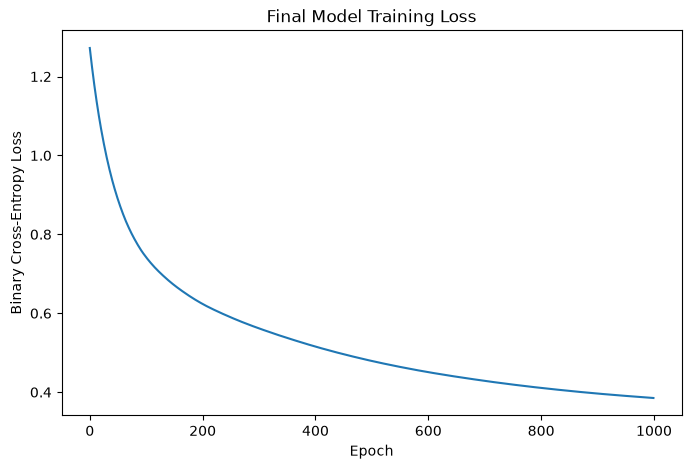

In [491]:
plt.figure(figsize=(8, 5))

plt.plot(final_loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Final Model Training Loss")

plt.show()

In [492]:
val_probs = predict_proba(X_val)

thresholds_to_test = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
]

threshold_results = []

for threshold in thresholds_to_test:

    val_pred = (
        val_probs >= threshold
    ).astype(int)

    val_accuracy = accuracy_score(
        y_val.ravel(),
        val_pred
    )

    val_precision = precision_score(
        y_val.ravel(),
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        y_val.ravel(),
        val_pred,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val.ravel(),
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": val_accuracy,
        "Precision": val_precision,
        "Recall": val_recall,
        "F1": val_f1
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.714286,0.617647,0.954545,0.750000
1,0.4,0.755102,0.678571,0.863636,0.760000
2,0.5,0.836735,0.791667,0.863636,0.826087
3,0.6,0.857143,0.857143,0.818182,0.837209
4,0.7,0.877551,1.000000,0.727273,0.842105


In [493]:
best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax(),
    "Threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.7


In [494]:
test_probs = predict_proba(X_test)

test_pred = (
    test_probs >= best_threshold
).astype(int)

In [495]:
test_accuracy = accuracy_score(
    y_test.ravel(),
    test_pred
)

test_precision = precision_score(
    y_test.ravel(),
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test.ravel(),
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test.ravel(),
    test_pred,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test.ravel(),
    test_probs
)

In [496]:
cm = confusion_matrix(
    y_test.ravel(),
    test_pred
)

print("Final Test Confusion Matrix:")
print(cm)

Final Test Confusion Matrix:
[[32  1]
 [ 8 20]]


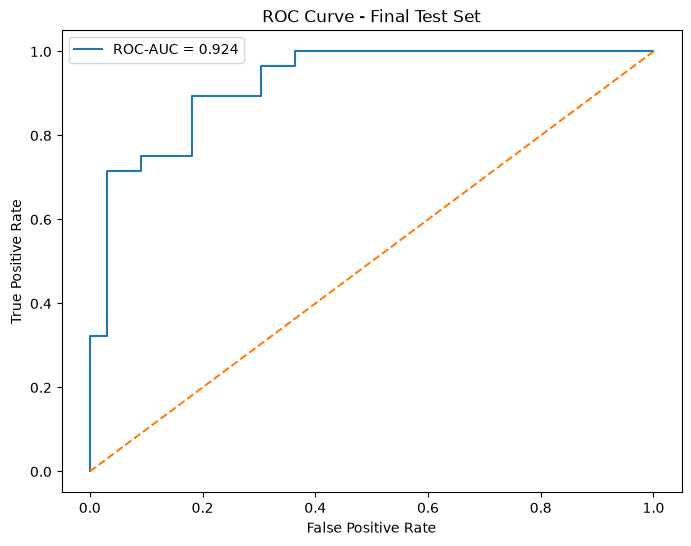

In [497]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test.ravel(),
    test_probs
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {test_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set")

plt.legend()
plt.show()

In [498]:
print("Final Model Performance")
print("-" * 35)

print(f"Learning Rate     : {best_learning_rate}")
print(f"Threshold         : {best_threshold:.2f}")
print(f"Test Accuracy     : {test_accuracy:.4f}")
print(f"Test Precision    : {test_precision:.4f}")
print(f"Test Recall       : {test_recall:.4f}")
print(f"Test F1 Score     : {test_f1:.4f}")
print(f"Test ROC-AUC      : {test_auc:.4f}")

Final Model Performance
-----------------------------------
Learning Rate     : 0.005
Threshold         : 0.70
Test Accuracy     : 0.8525
Test Precision    : 0.9524
Test Recall       : 0.7143
Test F1 Score     : 0.8163
Test ROC-AUC      : 0.9242
